# <font face = 'Impact' color = '#FFAEBC' > Getting Ready with our Second Mini-Project <font/>
#### <font face = 'Times New Roman' color = '#A16AE8'> Author and Trainer: Paolo Hilado MSc. (Data Science)<font/>
In this notebook, we will be importing packages and use them to load and explore data sets. We will be using the pandas package to load datasets and qdesc to explore both categorical and numerical variables. Functions to be used include pd.read_excel, pd.read_csv, head, qd.desc, qd.normcheck_dashboard, qd.freqdist_a, and qd.freqdist_to_excel.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# <font face = 'Impact' color = '#FFAEBC' > Exploring Sleep Hours during Weeknights <font/>

In [ ]:
# Importing the necessary packages for us to use certain functions.
import pandas as pd
import numpy as np
import qdesc as qd

In [ ]:
# Loading a data set (SleepData.xlsx) and storing it into a variable.
df = pd.read_excel("SleepData.xlsx")

In [ ]:
# Check the first 5 rows of the dataframe
df.head()

,Sex,Age,MaritalStatus,Employment,sleep(hrs)/weeknights
0,Male,30,Single,Permanent,8.85
1,Female,58,Married,Permanent,8.76
2,Female,60,Single,Permanent,8.49
3,Male,43,Single,Permanent,8.85
4,Female,43,Single,Permanent,8.73


In [ ]:
# Check the information of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 671 entries, 0 to 670
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Sex                    671 non-null    object 
 1   Age                    671 non-null    int64  
 2   MaritalStatus          671 non-null    object 
 3   Employment             671 non-null    object 
 4   sleep(hrs)/weeknights  671 non-null    float64
dtypes: float64(1), int64(1), object(3)
memory usage: 26.3+ KB


In [ ]:
# Using the desc function from the qdesc package to perform descriptive analysis.
qd.desc(df)

,count,mean,std,median,MAD,min,max,AD_stat,5% crit_value
Age,671.0,49.80,19.36,49.00,17.00,18.00,84.00,7.38,0.78
sleep(hrs)/weeknights,671.0,7.63,1.39,8.34,0.98,4.52,9.88,35.70,0.78


In [ ]:
# Generate descriptive analysis for sleep hours when grouped by sex.
qd.grp_desc(df, 'sleep(hrs)/weeknights', 'Sex')

,Sex,count,mean,std,median,mad,min,max,AD_stat,crit_5%
0,Female,350,7.67,1.36,8.33,0.96,4.52,9.88,17.14,0.78
1,Male,321,7.57,1.43,8.36,0.99,4.66,9.64,18.70,0.78


Exaplanation:

Females sleep a little longer (mean = 7.67 hours, std = 1.36) than males (mean = 7.57 hours, std = 1.43). The typical sleep time is almost the same, with a median of 8.33 hours for females and 8.36 hours for males. This shows both groups have very similar sleep patterns, with females just slightly higher.

In [ ]:
# Generate descriptive analysis for sleep hours when grouped by employment.
qd.grp_desc(df, 'sleep(hrs)/weeknights', 'Employment')

,Employment,count,mean,std,median,mad,min,max,AD_stat,crit_5%
0,Permanent,352,8.87,0.32,8.86,0.22,7.96,9.88,0.15,0.78
1,Probationary,319,6.26,0.60,6.22,0.40,4.52,7.90,0.36,0.78


Explanation:

Permanent employees sleep longer on average (mean = 8.87 hours, std = 0.32) compared to probationary employees (mean = 6.26 hours, std = 0.60). The medians also differ, with permanent workers at 8.86 hours and probationary workers at 6.22 hours, showing that permanent employees generally get about 2.5 more hours of sleep than those on probation.


In [ ]:
# Generate descriptive analysis for sleep hours when grouped by marital status.
qd.grp_desc(df, 'sleep(hrs)/weeknights', 'MaritalStatus')

,MaritalStatus,count,mean,std,median,mad,min,max,AD_stat,crit_5%
0,Married,333,7.67,1.40,8.44,0.88,4.66,9.64,19.32,0.78
1,Single,338,7.58,1.39,8.26,1.01,4.52,9.88,16.56,0.78


Explanation:

Married individuals sleep slightly longer on average (mean = 7.67 hours, std = 1.40) compared to singles (mean = 7.58 hours, std = 1.39). The medians are also close, with married at 8.44 hours and singles at 8.26 hours, suggesting both groups have very similar sleep patterns, with married people just a little higher.


Exception ignored in: <function ZipFile.__del__ at 0x78ff358de840>
Traceback (most recent call last):
  File "/usr/lib/python3.12/zipfile/__init__.py", line 1953, in __del__
    self.close()
  File "/usr/lib/python3.12/zipfile/__init__.py", line 1970, in close
    self.fp.seek(self.start_dir)
ValueError: seek of closed file



--- Variable: Age ---
  Anderson-Darling Statistic : 7.3813
  Critical Value (@ 5.0%) : 0.7820
  Decision : Reject Null


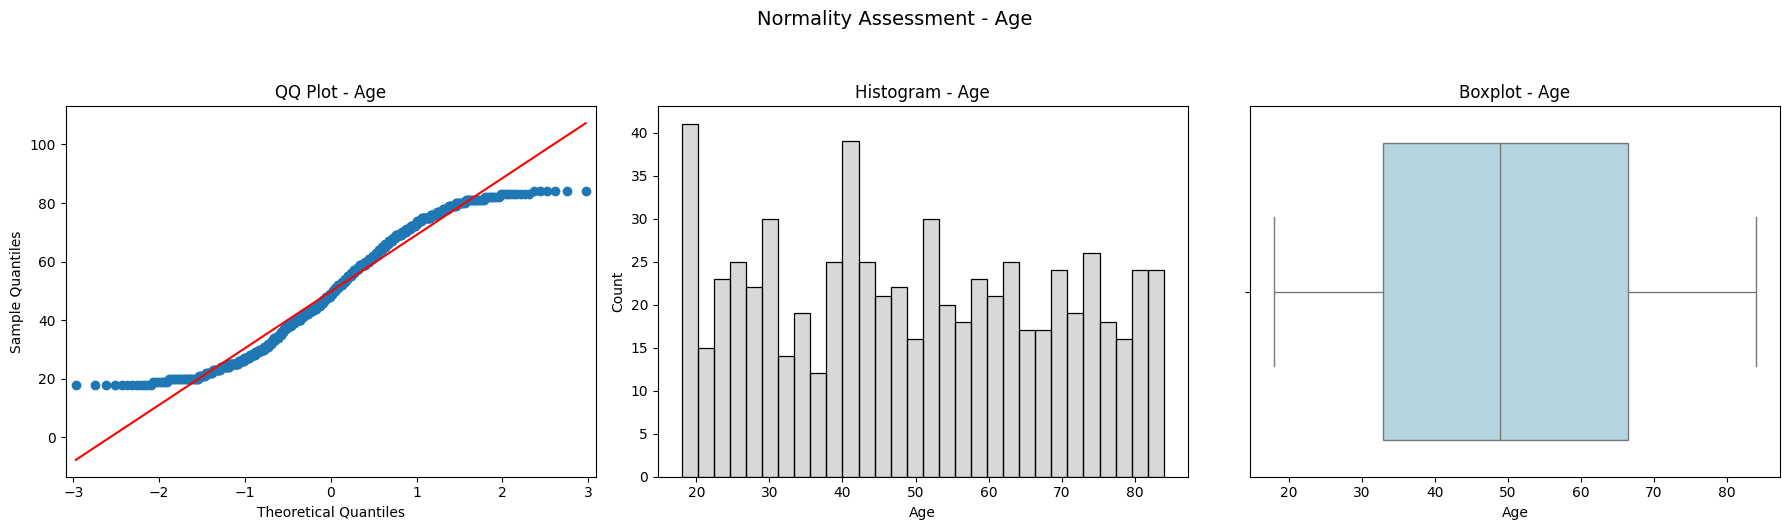


--- Variable: sleep(hrs)/weeknights ---
  Anderson-Darling Statistic : 35.6977
  Critical Value (@ 5.0%) : 0.7820
  Decision : Reject Null


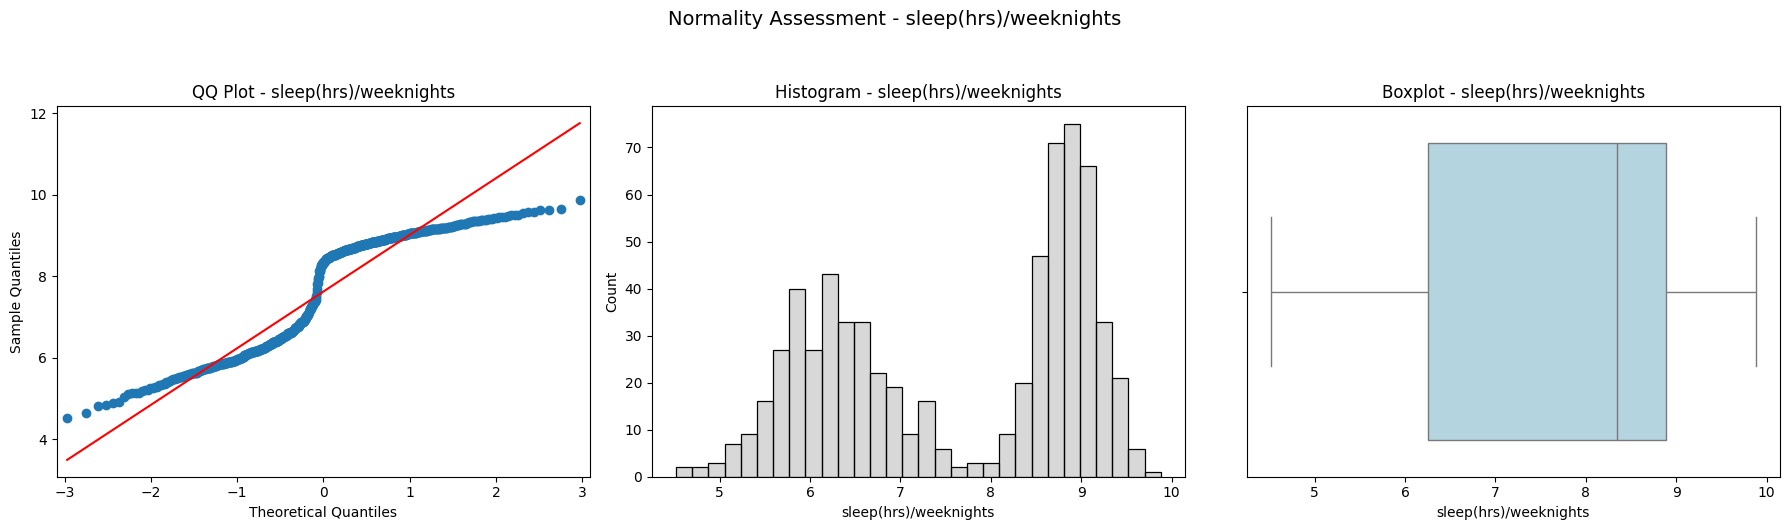

In [ ]:
# Use the desc function from the qdesc package to explore the data for assumption of normality.
qd.normcheck_dashboard(df)

Explanation:

The Anderson-Darling test shows a statistic of 7.38, which is much higher than the 5% critical value of 0.78. This means we reject the null hypothesis of normality. In other words, the distribution of Age does not follow a normal distribution.

on sleep hours:
The Anderson-Darling statistic for sleep hours on weeknights is 35.70, which is far greater than the 5% critical value of 0.78. This leads us to reject the null hypothesis, indicating that weeknight sleep duration does not follow a normal distribution.

In [ ]:
# Slicing the data frame to only include the single.
single = df[df['MaritalStatus'] == 'Single']
single.head()

,Sex,Age,MaritalStatus,Employment,sleep(hrs)/weeknights
0,Male,30,Single,Permanent,8.85
2,Female,60,Single,Permanent,8.49
3,Male,43,Single,Permanent,8.85
4,Female,43,Single,Permanent,8.73
6,Male,45,Single,Permanent,8.36


In [ ]:
# Confirm that the subset would only include those who are single.
print(single['MaritalStatus'].unique())

['Single']


In [ ]:
# Use the qdesc package to explore the data (only those who are Single) for assumption of normality.
qd.desc(single)

,count,mean,std,median,MAD,min,max,AD_stat,5% crit_value
Age,338.0,50.74,19.11,50.00,16.00,18.00,84.00,3.05,0.78
sleep(hrs)/weeknights,338.0,7.58,1.39,8.26,1.01,4.52,9.88,16.56,0.78


In [ ]:
# Slicing the data frame to only include the married.
married = df[df['MaritalStatus'] == 'Married']
married.head()

,Sex,Age,MaritalStatus,Employment,sleep(hrs)/weeknights
1,Female,58,Married,Permanent,8.76
5,Female,32,Married,Permanent,8.70
10,Female,29,Married,Permanent,9.05
11,Female,31,Married,Permanent,9.41
12,Male,38,Married,Permanent,8.94


In [ ]:
# Confirm that the subset is all married.
print(married['MaritalStatus'].unique())

['Married']


In [ ]:
# Use the qdesc package to explore the data for assumption of normality.
qd.desc(married)

,count,mean,std,median,MAD,min,max,AD_stat,5% crit_value
Age,333.0,48.86,19.6,48.00,17.00,18.00,84.00,4.71,0.78
sleep(hrs)/weeknights,333.0,7.67,1.4,8.44,0.88,4.66,9.64,19.32,0.78


In [ ]:
# Generate a frequency distribution for a specified variable: Sex
qd.freqdist(df, 'Sex')

,Sex,Count,Percentage
0,Female,350,52.16
1,Male,321,47.84


In [ ]:
# Generate a frequency distribution for a specified variable: Employment
# Frequency distribution for Employment
qd.freqdist(df,'Employment')


,Employment,Count,Percentage
0,Permanent,352,52.46
1,Probationary,319,47.54


In [ ]:
# Generate a frequency distribution for a specified variable: Marital Status
qd.freqdist(df,'MaritalStatus')

,MaritalStatus,Count,Percentage
0,Single,338,50.37
1,Married,333,49.63


In [ ]:
# Generate frequency distribution for all the categorical features from the said data frame.
qd.freqdist_a(df)

,Column,Value,Count,Percentage
0,Sex,Female,350,52.16
1,Sex,Male,321,47.84
2,MaritalStatus,Single,338,50.37
3,MaritalStatus,Married,333,49.63
4,Employment,Permanent,352,52.46
5,Employment,Probationary,319,47.54


Conclusion:

From the statistical normality tests, the Anderson-Darling results for variables such as Age (AD = 7.3813, p < 0.05) and Sleep Hours during Weeknights (AD = 35.6977, p < 0.05) indicate that their distributions deviate significantly from normality. This means parametric tests that assume normal distribution may not be suitable, and non-parametric approaches are more appropriate for further analysis.

When combined with the demographic data, the results show that the sample is diverse and balanced across sex, marital status, and employment type, strengthening the generalizability of the study. However, the non-normality of key variables highlights that future modeling and hypothesis testing must carefully account for distributional properties to avoid misleading conclusions.

In [ ]:
# Generating a frequency distribution but this time have it stored in an excel file and organized
# on a per sheet basis per categorical feature.

import pandas as pd


with pd.ExcelWriter("CategoricalFreqs.xlsx", engine="openpyxl") as writer:

    for col in df.select_dtypes(include=['object', 'category']).columns:

        res = pd.DataFrame({
            "Count": df[col].value_counts(),
            "Percentage": df[col].value_counts(normalize=True) * 100
        })


        res.to_excel(writer, sheet_name=col[:31])

